In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from adjustText import adjust_text

def compute_prevalence(
    df,
    split_col,
    split_values,
    sex_col="female",
    date_col=None,
    cutoff_date=None,
    target_prefix="target_",
    exclude_regex="(1pt_change|grade3plus|ecog)"
):
    """
    Returns a long dataframe with:
    target_name | Split | Sex | prevalence
    """

    df = df.copy()

    # Optional date-based split (for in-distribution)
    if date_col is not None and cutoff_date is not None:
        df[date_col] = pd.to_datetime(df[date_col], utc=True).dt.tz_localize(None)
        df[split_col] = df[date_col].apply(
            lambda x: split_values[0] if x < cutoff_date else split_values[1]
        )
    
    # convert sex_col to binary by mapping 1 to True and 0 otherwise
    df[sex_col] = df[sex_col].replace({1: True, 0: False, -1: False})

    df["Sex"] = df[sex_col].map({True: "Female", False: "Male"})

    # Keep relevant target columns
    target_cols = [
        c for c in df.columns
        if c.startswith(target_prefix) and not pd.Series(c).str.contains(exclude_regex).any()
    ]

    df_long = df.melt(
        id_vars=[split_col, "Sex"],
        value_vars=target_cols,
        var_name="target_name",
        value_name="value"
    )

    df_valid = df_long[df_long["value"] != -1]

    denom = (
        df_valid
        .groupby(["target_name", split_col])
        .size()
        .reset_index(name="denominator")
    )

    numer = (
        df_valid[df_valid["value"] == 1]
        .groupby(["target_name", split_col, "Sex"])
        .size()
        .reset_index(name="numerator")
    )

    merged = numer.merge(denom, on=["target_name", split_col])
    merged["prevalence"] = merged["numerator"] / merged["denominator"]

    return merged[["target_name", split_col, "Sex", "prevalence"]]

def reshape_prevalence(df_prev, split_col, splits, sexes=("Male", "Female")):
    wide = df_prev.pivot_table(
        index="target_name",
        columns=[split_col, "Sex"],
        values="prevalence"
    )

    # Ensure all combinations exist
    idx = pd.MultiIndex.from_product(
        [splits, sexes],
        names=[split_col, "Sex"]
    )
    wide = wide.reindex(columns=idx, fill_value=0)

    wide = wide.reset_index()
    wide.columns = ["target_name"] + [
        f"{s}_{sex}" for s, sex in wide.columns.tolist()[1:]
    ]

    return wide

def plot_id_ood_prevalence(
    df_id,
    df_ood,
    dict_mapping,
    cutoff_date=pd.Timestamp("2016-01-01"),
    colors={"Male": "#4C78A8", "Female": "#F58518"},
    ood_offset=0.15,
    figsize=(11, 6)
):
    # -----------------------
    # In-distribution
    # -----------------------
    prev_id = compute_prevalence(
        df_id,
        split_col="Split",
        split_values=("Devt", "Test"),
        date_col="treatment_date",
        cutoff_date=cutoff_date
    )
    wide_id = reshape_prevalence(
        prev_id,
        split_col="Split",
        splits=("Devt", "Test")
    )

    # -----------------------
    # Out-of-distribution
    # -----------------------
    df_ood = df_ood.copy()
    df_ood["Split"] = "OOD"

    prev_ood = compute_prevalence(
        df_ood,
        split_col="Split",
        split_values=("OOD",)
    )
    wide_ood = reshape_prevalence(
        prev_ood,
        split_col="Split",
        splits=("OOD",)
    )

    # -----------------------
    # Merge & clean labels
    # -----------------------
    result = wide_id.merge(wide_ood, on="target_name", how="left").fillna(0)

    result["target_name"] = (
        result["target_name"]
        .str.replace("_", "-", regex=False)
        .replace(dict_mapping)
    )

    result["Devt_Total"] = result["Devt_Male"] + result["Devt_Female"]
    result = result.sort_values("Devt_Total", ascending=True)

    # -----------------------
    # Compute baselines
    # -----------------------
    devt_extent = (result["Devt_Male"] + result["Devt_Female"]).max()
    test_extent = (result["Test_Male"] + result["Test_Female"]).max()
    ood_extent  = (result["OOD_Male"]  + result["OOD_Female"]).max()

    # Fixed baseline for OOD (same for all rows)
    ood_base = test_extent + ood_offset

    # -----------------------
    # Plot
    # -----------------------
    fig, ax = plt.subplots(figsize=figsize)

    # Devt (left)
    ax.barh(
        result["target_name"],
        -result["Devt_Male"],
        color=colors["Male"],
        label="Male"
    )
    ax.barh(
        result["target_name"],
        -result["Devt_Female"],
        left=-result["Devt_Male"],
        color=colors["Female"],
        label="Female"
    )

    # Test (right)
    ax.barh(
        result["target_name"],
        result["Test_Male"],
        color=colors["Male"]
    )
    ax.barh(
        result["target_name"],
        result["Test_Female"],
        left=result["Test_Male"],
        color=colors["Female"]
    )

    # OOD (separate region — removed alpha for opacity)
    ax.barh(
        result["target_name"],
        result["OOD_Male"],
        left=ood_base,
        color=colors["Male"]
    )
    ax.barh(
        result["target_name"],
        result["OOD_Female"],
        left=ood_base + result["OOD_Male"],
        color=colors["Female"]
    )

    # -----------------------
    # Formatting
    # -----------------------
    ax.axvline(0, color="black", lw=1)
    ax.axvline(ood_base, color="black", lw=1, linestyle="--")

    # Explicit x-limits so OOD is visible
    ax.set_xlim(
        left=-devt_extent * 1.1,
        right=ood_base + ood_extent * 1.2
    )

    ax.set_xlabel("Prevalence", fontsize=16)
    ax.set_title("Adverse event prevalence (ID vs OOD)", fontsize=18)
    ax.spines[["top", "right"]].set_visible(False)

    xticks = ax.get_xticks()
    ax.set_xticklabels([f"{abs(x):.1f}" for x in xticks])

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(
        [by_label["Male"], by_label["Female"]],
        ["Male", "Female"],
        loc="lower left",
        fontsize=14
    )

    # -----------------------
    # Add annotations with arrows
    # -----------------------
    height_xy = 0.45  # Position near the top of the plot
    
    # EPR (08-15) - Development set (left side)
    ax.annotate("EPR (08-15)",
                xy=(0.3, height_xy), xycoords='axes fraction',
                xytext=(0.3-0.15, height_xy), textcoords='axes fraction',
                arrowprops=dict(arrowstyle="->", lw=2, color="black"),
                ha="right", va="center", fontsize=14, fontweight='bold')

    # EPR (16-19) - Test set (right side)
    ax.annotate("EPR (16-19)",
                xy=(0.45, height_xy), xycoords='axes fraction',
                xytext=(0.45 + 0.15, height_xy), textcoords='axes fraction',
                arrowprops=dict(arrowstyle="->", lw=2, color="black"),
                ha="left", va="center", fontsize=14, fontweight='bold')

    # EPIC (22-24) - OOD set (far right)
    ax.annotate("EPIC (22-24)",
                xy=(0.75, height_xy/2), xycoords='axes fraction',
                xytext=(0.75 - 0.15, height_xy/2), textcoords='axes fraction',
                arrowprops=dict(arrowstyle="->", lw=2, color="black"),
                ha="right", va="center", fontsize=14, fontweight='bold')

    plt.tight_layout()
    return fig, ax

/var/folders/xl/pdrtfmy950768yqxtqn387s80000gp/T/ipykernel_92236/3516163664.py:38: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if c.startswith(target_prefix) and not pd.Series(c).str.contains(exclude_regex).any()
/var/folders/xl/pdrtfmy950768yqxtqn387s80000gp/T/ipykernel_92236/3516163664.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[sex_col] = df[sex_col].replace({1: True, 0: False, -1: False})
/var/folders/xl/pdrtfmy950768yqxtqn387s80000gp/T/ipykernel_92236/3516163664.py:38: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if c.startswith(target_prefix) and not pd.Series(c)

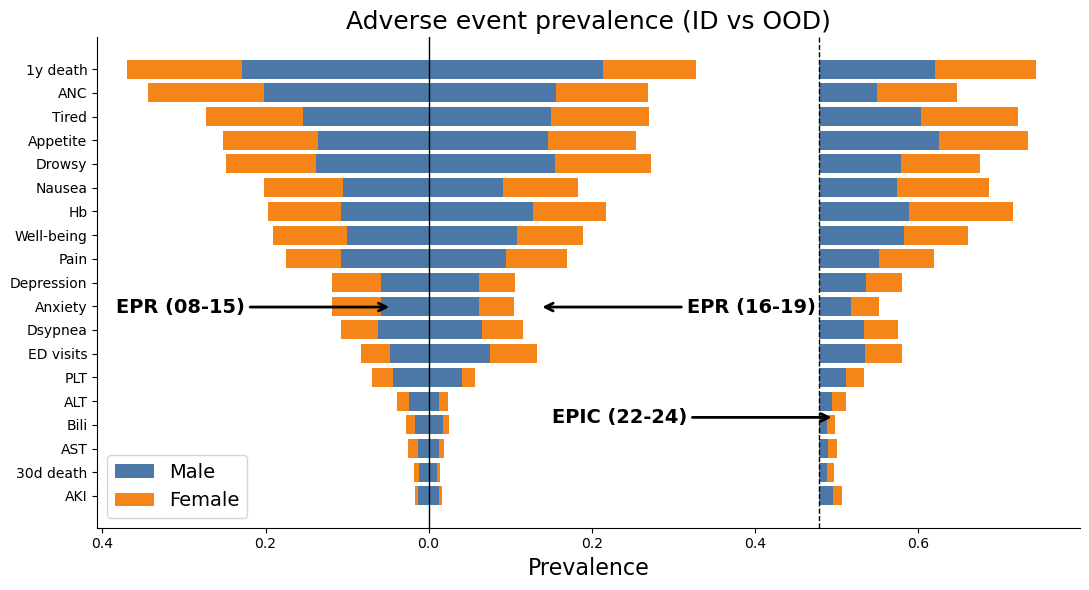

In [81]:
fig, ax = plot_id_ood_prevalence(df_idd, df_ood, dict_mapping)

In [82]:
save_dir = '/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/results/plots/schema'
fig.savefig(f"{save_dir}/prevalence_id_ood_schema.png", dpi=300)